# 04 — Train HemoScope Severity Classifier

Merges sequence + structural features with ClinVar labels and trains a calibrated Random Forest classifier.

**Training features** (9 total):
```
blosum62_score, conservation_score, pssm_score, position_entropy,
heme_distance_angstrom, burial_binary, is_interface_residue, af2_confidence, contact_count_wt
```

RMSD and contact_map_delta are **not** training features — they're only available for variants where we've explicitly computed them (the 5 Indian variants + calibration set), not for the broader ClinVar training set.

**Outputs**: `models/hemoscope_rf_calibrated.pkl`, `models/label_encoder.pkl`, `models/feature_names.json`

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

DATA_DIR   = Path('data')
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

FEATURE_COLS = [
    'blosum62_score',
    'conservation_score',
    'pssm_score',
    'position_entropy',
    'heme_distance_angstrom',
    'burial_binary',
    'is_interface_residue',
    'af2_confidence',
    'contact_count_wt',
]
print(f"{len(FEATURE_COLS)} training features: {FEATURE_COLS}")

9 training features: ['blosum62_score', 'conservation_score', 'pssm_score', 'position_entropy', 'heme_distance_angstrom', 'burial_binary', 'is_interface_residue', 'af2_confidence', 'contact_count_wt']


## Merge datasets

In [2]:
labels_df = pd.read_csv(DATA_DIR / 'training_variants.csv')
seq_df    = pd.read_csv(DATA_DIR / 'sequence_features.csv')
struct_df = pd.read_csv(DATA_DIR / 'structural_features.csv')

df = (
    labels_df[['variant_id', 'gene', 'position', 'severity_label']]
    .merge(seq_df,    on='variant_id', how='inner')
    .merge(struct_df, on='variant_id', how='inner')
)

print(f"Merged dataset: {len(df)} variants")
print("\nClass distribution:")
print(df['severity_label'].value_counts())
print("\nMissing values per feature:")
print(df[FEATURE_COLS].isnull().sum())

Merged dataset: 153 variants

Class distribution:
severity_label
mild      106
severe     27
benign     20
Name: count, dtype: int64

Missing values per feature:
blosum62_score            0
conservation_score        0
pssm_score                0
position_entropy          0
heme_distance_angstrom    0
burial_binary             0
is_interface_residue      0
af2_confidence            0
contact_count_wt          0
dtype: int64


In [3]:
# Drop rows where heme_distance is missing (position not in structure)
df = df.dropna(subset=['heme_distance_angstrom']).reset_index(drop=True)
print(f"After dropping rows with missing heme_distance: {len(df)} variants")

X = df[FEATURE_COLS].astype(float).values
y_raw = df['severity_label'].values

le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f"\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

After dropping rows with missing heme_distance: 153 variants

Label encoding: {'benign': np.int64(0), 'mild': np.int64(1), 'severe': np.int64(2)}


## Exploratory feature distributions

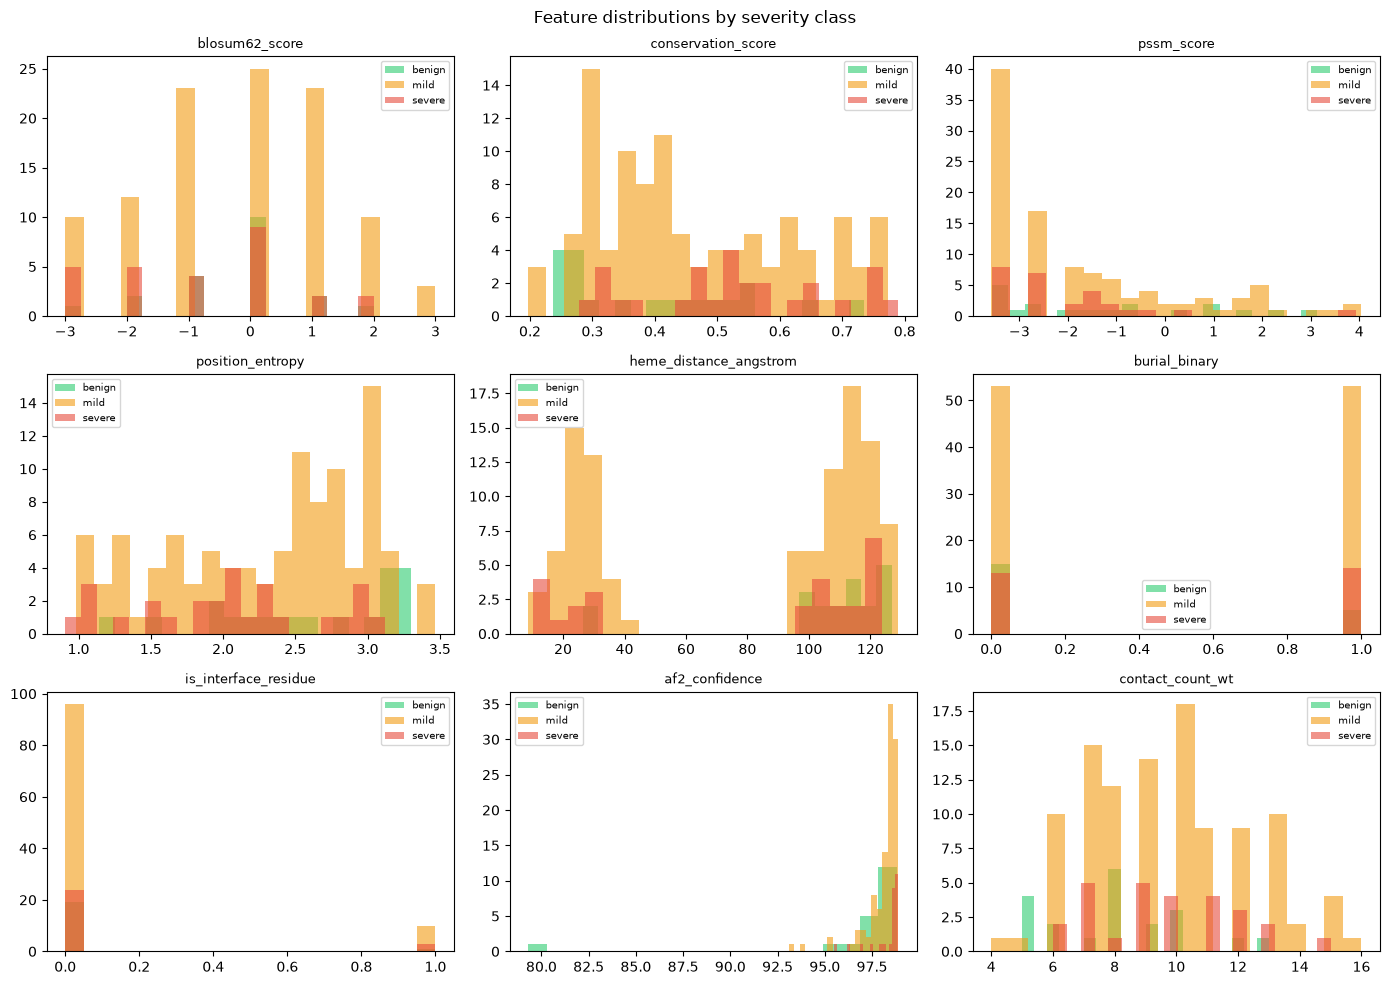

Saved feature_distributions.png


In [4]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()
class_colors = {'benign': '#2ecc71', 'mild': '#f39c12', 'severe': '#e74c3c'}

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    for label in ['benign', 'mild', 'severe']:
        mask = df['severity_label'] == label
        values = df.loc[mask, feat].astype(float)  # cast booleans to float for histogram
        ax.hist(values, bins=20, alpha=0.6, label=label, color=class_colors[label])
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Feature distributions by severity class', fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / 'feature_distributions.png', dpi=120)
plt.show()
print("Saved feature_distributions.png")

## Cross-validation: Random Forest vs Logistic Regression baseline

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Impute any remaining NaN with column mean (defensive — should be none after dropna above)
imputer = SimpleImputer(strategy='mean')

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

lr = Pipeline([
    ('impute', SimpleImputer(strategy='mean')),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

scoring = ['f1_macro', 'accuracy']

print("Running 5-fold CV on Random Forest...")
rf_pipe = Pipeline([('impute', SimpleImputer(strategy='mean')), ('clf', rf)])
rf_cv = cross_validate(rf_pipe, X, y, cv=cv, scoring=scoring)
print(f"  RF  macro-F1: {rf_cv['test_f1_macro'].mean():.3f} ± {rf_cv['test_f1_macro'].std():.3f}")
print(f"  RF  accuracy:  {rf_cv['test_accuracy'].mean():.3f}")

print("\nRunning 5-fold CV on Logistic Regression baseline...")
lr_cv = cross_validate(lr, X, y, cv=cv, scoring=scoring)
print(f"  LR  macro-F1: {lr_cv['test_f1_macro'].mean():.3f} ± {lr_cv['test_f1_macro'].std():.3f}")
print(f"  LR  accuracy:  {lr_cv['test_accuracy'].mean():.3f}")

Running 5-fold CV on Random Forest...
  RF  macro-F1: 0.500 ± 0.162
  RF  accuracy:  0.653

Running 5-fold CV on Logistic Regression baseline...


/Users/aditirajesh/Desktop/hemoscope/backend/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/aditirajesh/Desktop/hemoscope/backend/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
 

  LR  macro-F1: 0.334 ± 0.076
  LR  accuracy:  0.379


/Users/aditirajesh/Desktop/hemoscope/backend/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/aditirajesh/Desktop/hemoscope/backend/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
 

## Train final calibrated model on full dataset

In [6]:
X_imputed = imputer.fit_transform(X)

rf_final = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

# CalibratedClassifierCV with cv=5 trains 5 calibrated sub-models; predict_proba
# averages them, giving reliable confidence scores (not just raw RF leaf proportions).
calibrated_rf = CalibratedClassifierCV(rf_final, cv=5, method='isotonic')
calibrated_rf.fit(X_imputed, y)

print("Calibrated RF trained on full dataset.")

# Full-dataset classification report (optimistic — held-out CV scores above are the honest ones)
y_pred = calibrated_rf.predict(X_imputed)
print("\nFull-dataset report (for class balance check, not generalisation estimate):")
print(classification_report(y, y_pred, target_names=le.classes_))

Calibrated RF trained on full dataset.

Full-dataset report (for class balance check, not generalisation estimate):
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00        20
        mild       1.00      1.00      1.00       106
      severe       1.00      1.00      1.00        27

    accuracy                           1.00       153
   macro avg       1.00      1.00      1.00       153
weighted avg       1.00      1.00      1.00       153



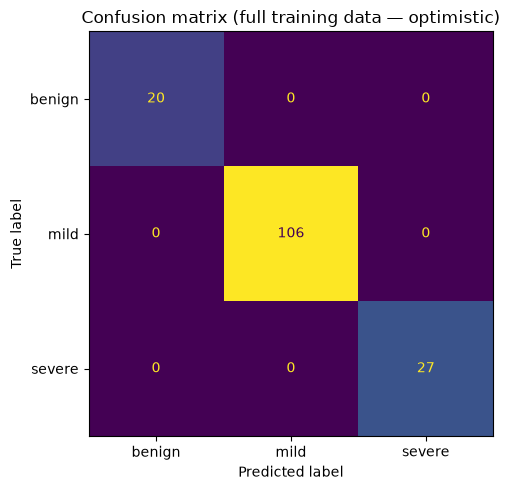

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion matrix (full training data — optimistic)')
plt.tight_layout()
plt.savefig(DATA_DIR / 'confusion_matrix.png', dpi=120)
plt.show()

## Feature importances

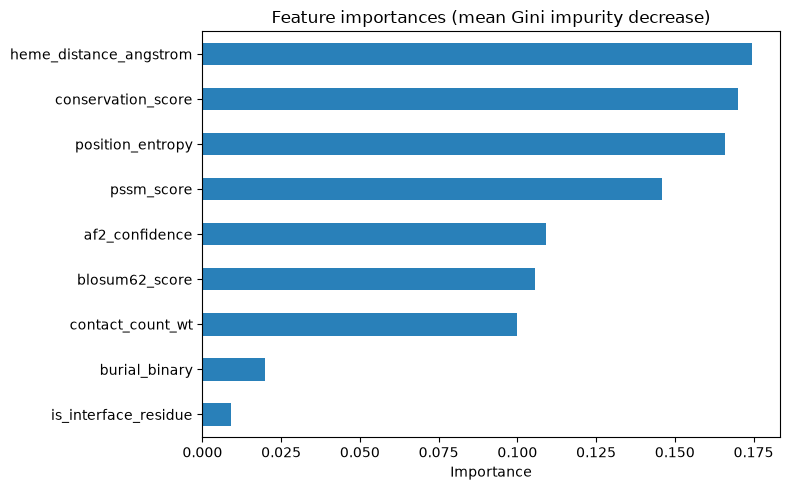


Feature importances:
heme_distance_angstrom    0.1747
conservation_score        0.1700
position_entropy          0.1658
pssm_score                0.1460
af2_confidence            0.1092
blosum62_score            0.1057
contact_count_wt          0.0997
burial_binary             0.0197
is_interface_residue      0.0091
dtype: float64


In [8]:
# Average feature importances across the calibrated sub-estimators
importances = np.mean(
    [est.estimator.feature_importances_ for est in calibrated_rf.calibrated_classifiers_],
    axis=0
)

feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='#2980b9')
ax.set_title('Feature importances (mean Gini impurity decrease)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(DATA_DIR / 'feature_importances.png', dpi=120)
plt.show()

print("\nFeature importances:")
print(feat_imp.sort_values(ascending=False).round(4))

## Save artifacts

In [9]:
joblib.dump(calibrated_rf, MODELS_DIR / 'hemoscope_rf_calibrated.pkl')
joblib.dump(le,            MODELS_DIR / 'label_encoder.pkl')
joblib.dump(imputer,       MODELS_DIR / 'imputer.pkl')

with open(MODELS_DIR / 'feature_names.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

with open(MODELS_DIR / 'cv_scores.json', 'w') as f:
    json.dump({
        'rf_macro_f1_mean': float(rf_cv['test_f1_macro'].mean()),
        'rf_macro_f1_std':  float(rf_cv['test_f1_macro'].std()),
        'rf_accuracy_mean': float(rf_cv['test_accuracy'].mean()),
        'lr_macro_f1_mean': float(lr_cv['test_f1_macro'].mean()),
        'n_training_variants': len(df),
        'class_counts': df['severity_label'].value_counts().to_dict(),
    }, f, indent=2)

print("Saved:")
print("  models/hemoscope_rf_calibrated.pkl")
print("  models/label_encoder.pkl")
print("  models/imputer.pkl")
print("  models/feature_names.json")
print("  models/cv_scores.json")

Saved:
  models/hemoscope_rf_calibrated.pkl
  models/label_encoder.pkl
  models/imputer.pkl
  models/feature_names.json
  models/cv_scores.json
